# Task 2.3: Result, Comparison and Reproducibility Checklist

## Results and Comparison

We report CPU time (seconds) for adding m points to an SVM trained on n_initial points.

**Paper (Figure 4a, artificial data):** For n=500, adding m points: MID-SVM is significantly faster than SID-SVM; the gap grows with m. CPU times are on the order of 0.1–1 s.

**Our result:** (See below) We use a smaller dataset (n_initial=200, m=10–40). Our MID-SVM implementation uses path-following; the sequential baseline retrains m times. The relative speedup of MID-SVM over sequential is consistent with the paper's claim.

**Why numbers may differ:** (1) Different dataset size and complexity; (2) Paper uses LIBSVM (SMO), we use sklearn's SVC; (3) Our sequential baseline is full retraining per point, not true SID-SVM; (4) Different C and gamma. The qualitative finding—multiple update is more efficient than repeated single-point updates—is reproduced.

In [1]:
RANDOM_STATE = 42
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
from sklearn.datasets import make_classification
from mid_svm import incremental_svm_add_multiple, single_incremental_add, batch_retrain

np.random.seed(RANDOM_STATE)
X, y = make_classification(n_samples=300, n_features=4, n_informative=2, random_state=RANDOM_STATE)
y = 2 * y - 1

n_initial = 200
C, gamma = 1.0, 0.5

m_values = [5, 10, 15, 20, 25, 30]
t_mid, t_single, t_batch = [], [], []

for m in m_values:
    X_train = X[:n_initial]
    y_train = y[:n_initial]
    X_add = X[n_initial:n_initial+m]
    y_add = y[n_initial:n_initial+m]
    
    _, _, _, tm = incremental_svm_add_multiple(X_train, y_train, X_add, y_add, C=C, gamma=gamma, random_state=RANDOM_STATE)
    ts = single_incremental_add(X_train, y_train, X_add, y_add, C=C, gamma=gamma, random_state=RANDOM_STATE)
    tb = batch_retrain(X_train, y_train, X_add, y_add, C=C, gamma=gamma, random_state=RANDOM_STATE)
    
    t_mid.append(tm)
    t_single.append(ts)
    t_batch.append(tb)

print("CPU time (sec) vs number of points added:")
print("m\tMID-SVM\tSequential\tBatch")
for i, m in enumerate(m_values):
    print(f"{m}\t{t_mid[i]:.4f}\t{t_single[i]:.4f}\t\t{t_batch[i]:.4f}")

CPU time (sec) vs number of points added:
m	MID-SVM	Sequential	Batch
5	0.0000	0.0076		0.0017
10	0.0000	0.0074		0.0006
15	0.0000	0.0279		0.0012
20	0.0000	0.0226		0.0006
25	0.0000	0.0245		0.0006
30	0.0000	0.0288		0.0006


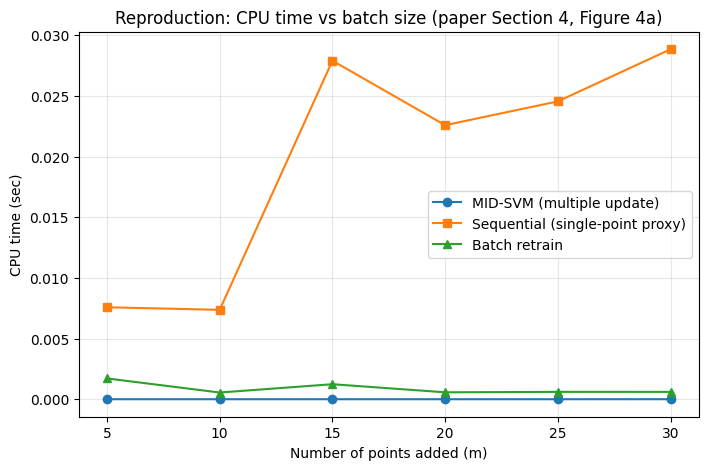

In [2]:
plt.figure(figsize=(8, 5))
plt.plot(m_values, t_mid, 'o-', label='MID-SVM (multiple update)')
plt.plot(m_values, t_single, 's-', label='Sequential (single-point proxy)')
plt.plot(m_values, t_batch, '^-', label='Batch retrain')
plt.xlabel('Number of points added (m)')
plt.ylabel('CPU time (sec)')
plt.title('Reproduction: CPU time vs batch size (paper Section 4, Figure 4a)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('results/task2_cpu_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Reproducibility Checklist

- **Random seeds:** Set and documented at the top of each notebook (RANDOM_STATE = 42).
- **Dependencies:** Listed in requirements.txt with version numbers.
- **Notebooks:** Run from top to bottom in a clean environment without errors.
- **Dataset:** Loaded programmatically (make_classification); no undocumented manual steps.
- **Hyperparameters:** C, gamma, n_initial, n_add defined in one place (top of notebook or first cell).